In [5]:
import os 
import numpy as np
import pandas as pd
from methyldl.deconvolution.uxm import load_atlas
import pickle

#### Analyze top-25 regions

In [2]:
import sys
atlas_location = "../../UXM_deconv/supplemental/Atlas.U25.l4.hg38.full.tsv"
atlas, ref_cells = load_atlas(atlas_location)
atlas = atlas.sort_values(by=["chr", "start", "end"], ascending=True).reset_index(drop=True)

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import entropy

def score_methylation_regions(df):
    # Separate metadata columns from cell-type data columns
    metadata_cols = ['chr', 'start', 'end', 'startCpG', 'endCpG', 'target', 'name', 'direction']
    cell_type_cols = [c for c in df.columns if c not in metadata_cols]
    
    results = []
    
    for idx, row in df.iterrows():
        target_cell = row['target']
        
        # Extract target value and background values
        target_val = row[target_cell]
        obs_vals = row[cell_type_cols].astype(float).values
        bg_vals = [row[c] for c in cell_type_cols if c != target_cell]
        
        # 1. Basic Entropy
        # Normalize observed values to create a valid probability distribution
        obs_sum = np.sum(obs_vals)
        if obs_sum > 0:
            q_dist = obs_vals / obs_sum
        else:
            q_dist = np.ones_like(obs_vals) / len(obs_vals) # uniform fallback if all are zero
            
        ent = entropy(q_dist, base=2)
        
        # 2. KL-Divergence
        # P is the ideal distribution (1 for target cell, 0 elsewhere)
        p_dist = np.zeros_like(obs_vals)
        target_idx = cell_type_cols.index(target_cell)
        p_dist[target_idx] = 1.0
        
        kl_div = entropy(p_dist, q_dist, base=2)
        
        # 3. Proxy GSC (Target - Max Background)
        max_bg = np.max(bg_vals)
        gsc = target_val - max_bg
        
        # 4. Delta from Average Background (Target - Mean Background)
        mean_bg = np.mean(bg_vals)
        delta_avg = target_val - mean_bg
        
        results.append({
            'name': row['name'],
            'entropy': ent,
            'kl_divergence': kl_div,
            'proxy_GSC': gsc,
            'delta_avg_bg': delta_avg
        })

    # Convert results to DataFrame and merge with original
    res_df = pd.DataFrame(results)
    final_df = pd.merge(df, res_df, on='name')
    
    return final_df

# Usage assuming 'df' is your full pandas DataFrame:
scored_df = score_methylation_regions(atlas)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_methylation_metrics(scored_df):
    """
    Takes a DataFrame containing methylation metrics and target labels, 
    and outputs a 2x2 grid of boxplots ranked by the median of each metric.
    """
    # Tuple format: (Column Name, True if Ascending/Lower-is-better, Title)
    metrics_info = [
        ('entropy', True, 'Entropy (Lower is better)'),
        ('kl_divergence', True, 'KL-Divergence (Lower is better)'),
        ('proxy_GSC', False, 'Proxy GSC (Higher is better)'),
        ('delta_avg_bg', False, 'Delta Avg Background (Higher is better)')
    ]

    fig, axes = plt.subplots(2, 2, figsize=(28, 12))
    axes = axes.flatten()

    # Create a copy to prevent SettingWithCopy warnings
    plot_df = scored_df.copy()

    for i, (metric, is_ascending, title) in enumerate(metrics_info):
        ax = axes[i]
        
        # 1. Calculate medians for the target cell types for this specific metric
        medians = plot_df.groupby('target')[metric].median()
        
        # 2. Sort targets. 
        # If lower is better (ascending=True), rank 1 has the lowest median.
        sorted_targets = medians.sort_values(ascending=is_ascending).index.tolist()
        
        # 3. Create a dictionary to map target to 'Rank. Target'
        ranked_labels = {t: f"{rank+1}. {t}" for rank, t in enumerate(sorted_targets)}
        
        # 4. Create a temporary column with ranked names
        rank_col_name = f'ranked_{metric}'
        plot_df[rank_col_name] = plot_df['target'].map(ranked_labels)
        
        # 5. Define the ordered list of categories for the x-axis
        order = [ranked_labels[t] for t in sorted_targets]
        
        # 6. Plot the boxplot
        sns.boxplot(
            data=plot_df, 
            x=rank_col_name, 
            y=metric, 
            order=order, 
            ax=ax, 
            palette='viridis'
        )
        
        # Prettify the axes
        ax.set_title(title, fontsize=14, pad=10)
        ax.set_xlabel('Target Cell (Ranked)', fontsize=12)
        ax.set_ylabel(metric, fontsize=12)
        ax.tick_params(axis='x', rotation=90)

    # Automatically adjust subplots to fit into figure area
    plt.tight_layout()
    
    # Save or show the plot
    plt.savefig('ranked_metrics_boxplots.png')
    plt.show()

In [47]:
with open("per_region_mccs_test.pkl", "rb") as f:
    per_region_mccs = pickle.load(f)

In [48]:
scored_df_mcc = pd.merge(scored_df, per_region_mccs, on="name")

In [49]:
scored_df_mcc.dropna(inplace=True)
scored_df_mcc["kl_divergence"][scored_df_mcc["kl_divergence"]>10]=sorted(scored_df_mcc["kl_divergence"])[-2]

/tmp/ipykernel_405796/4061365006.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  scored_df_mcc["kl_divergence"][scored_df_mcc["kl_divergence"]>10]=sorted(scored_df_mcc["kl_divergence"])[-2]
/tmp/ipykernel_405796/4061365006.py:2: SettingW

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def plot_regression(x, y, x_label='X-axis', y_label='Y-axis'):
    """
    Plots a scatter plot of x and y, fits a linear regression line,
    and displays the R-squared value and regression equation.
    """
    # 1. Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    # 2. Calculate R-squared
    r_squared = r_value**2
    
    # 3. Create the fitted line data
    # Equation: y = mx + b
    line = slope * np.array(x) + intercept
    
    # 4. Visualization
    plt.figure(figsize=(10, 6))
    
    # Scatter plot of raw data
    plt.scatter(x, y, alpha=0.6, edgecolors='w', label='Data Points')
    
    # Regression line
    plt.plot(x, line, color='red', linewidth=2, 
             label=f'Fitted Line: y={slope:.2f}x + {intercept:.2f}')
    
    # 5. Add R2 Annotation
    # We place the text in the "upper left" of the plot area
    plt.text(0.05, 0.95, f'$R^2 = {r_squared:.3f}$', 
             transform=plt.gca().transAxes, 
             fontsize=14, verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    
    # Aesthetics
    plt.title(f'Linear Regression: {y_label} vs {x_label}', fontsize=16)
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.show()

In [82]:
scored_df_mcc[scored_df_mcc["target"]=="Adipocytes"].loc[571]

chr                                    chr3
start                              53223941
end                                53224385
startCpG                            5063628
endCpG                              5063636
target                           Adipocytes
name                 chr3:53223941-53224385
direction                                 U
Adipocytes                            0.581
Bladder-Ep                            0.006
Blood-B                               0.009
Blood-Granul                            0.0
Blood-Mono+Macro                      0.006
Blood-NK                                0.0
Blood-T                                 0.0
Bone-Osteob                           0.071
Breast-Basal-Ep                         0.0
Breast-Luminal-Ep                       0.0
Colon-Ep                                0.0
Colon-Fibro                             0.0
Dermal-Fibro                          0.029
Endothel                              0.102
Epid-Kerat                      

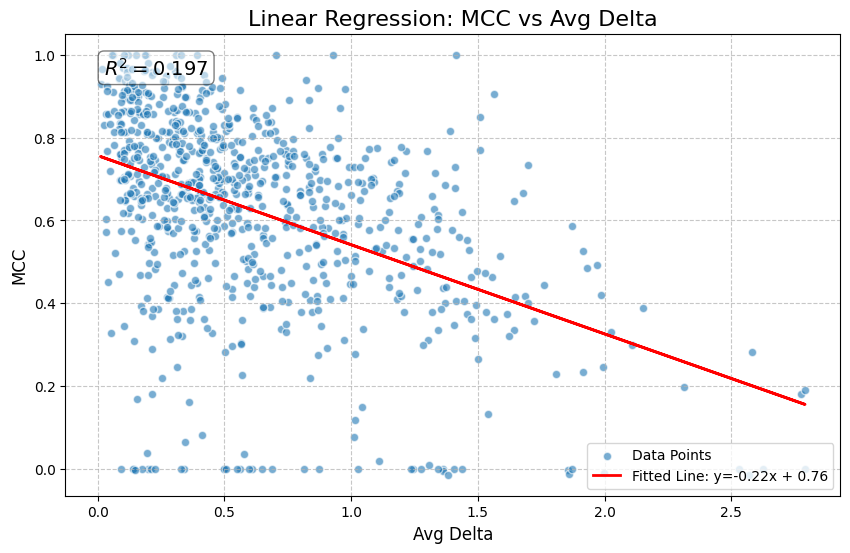

In [54]:
plot_regression(scored_df_mcc["kl_divergence"], scored_df_mcc["mcc"], x_label="Avg Delta", y_label="MCC")

/tmp/ipykernel_329002/797545497.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_329002/797545497.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_329002/797545497.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_329002/797545497.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


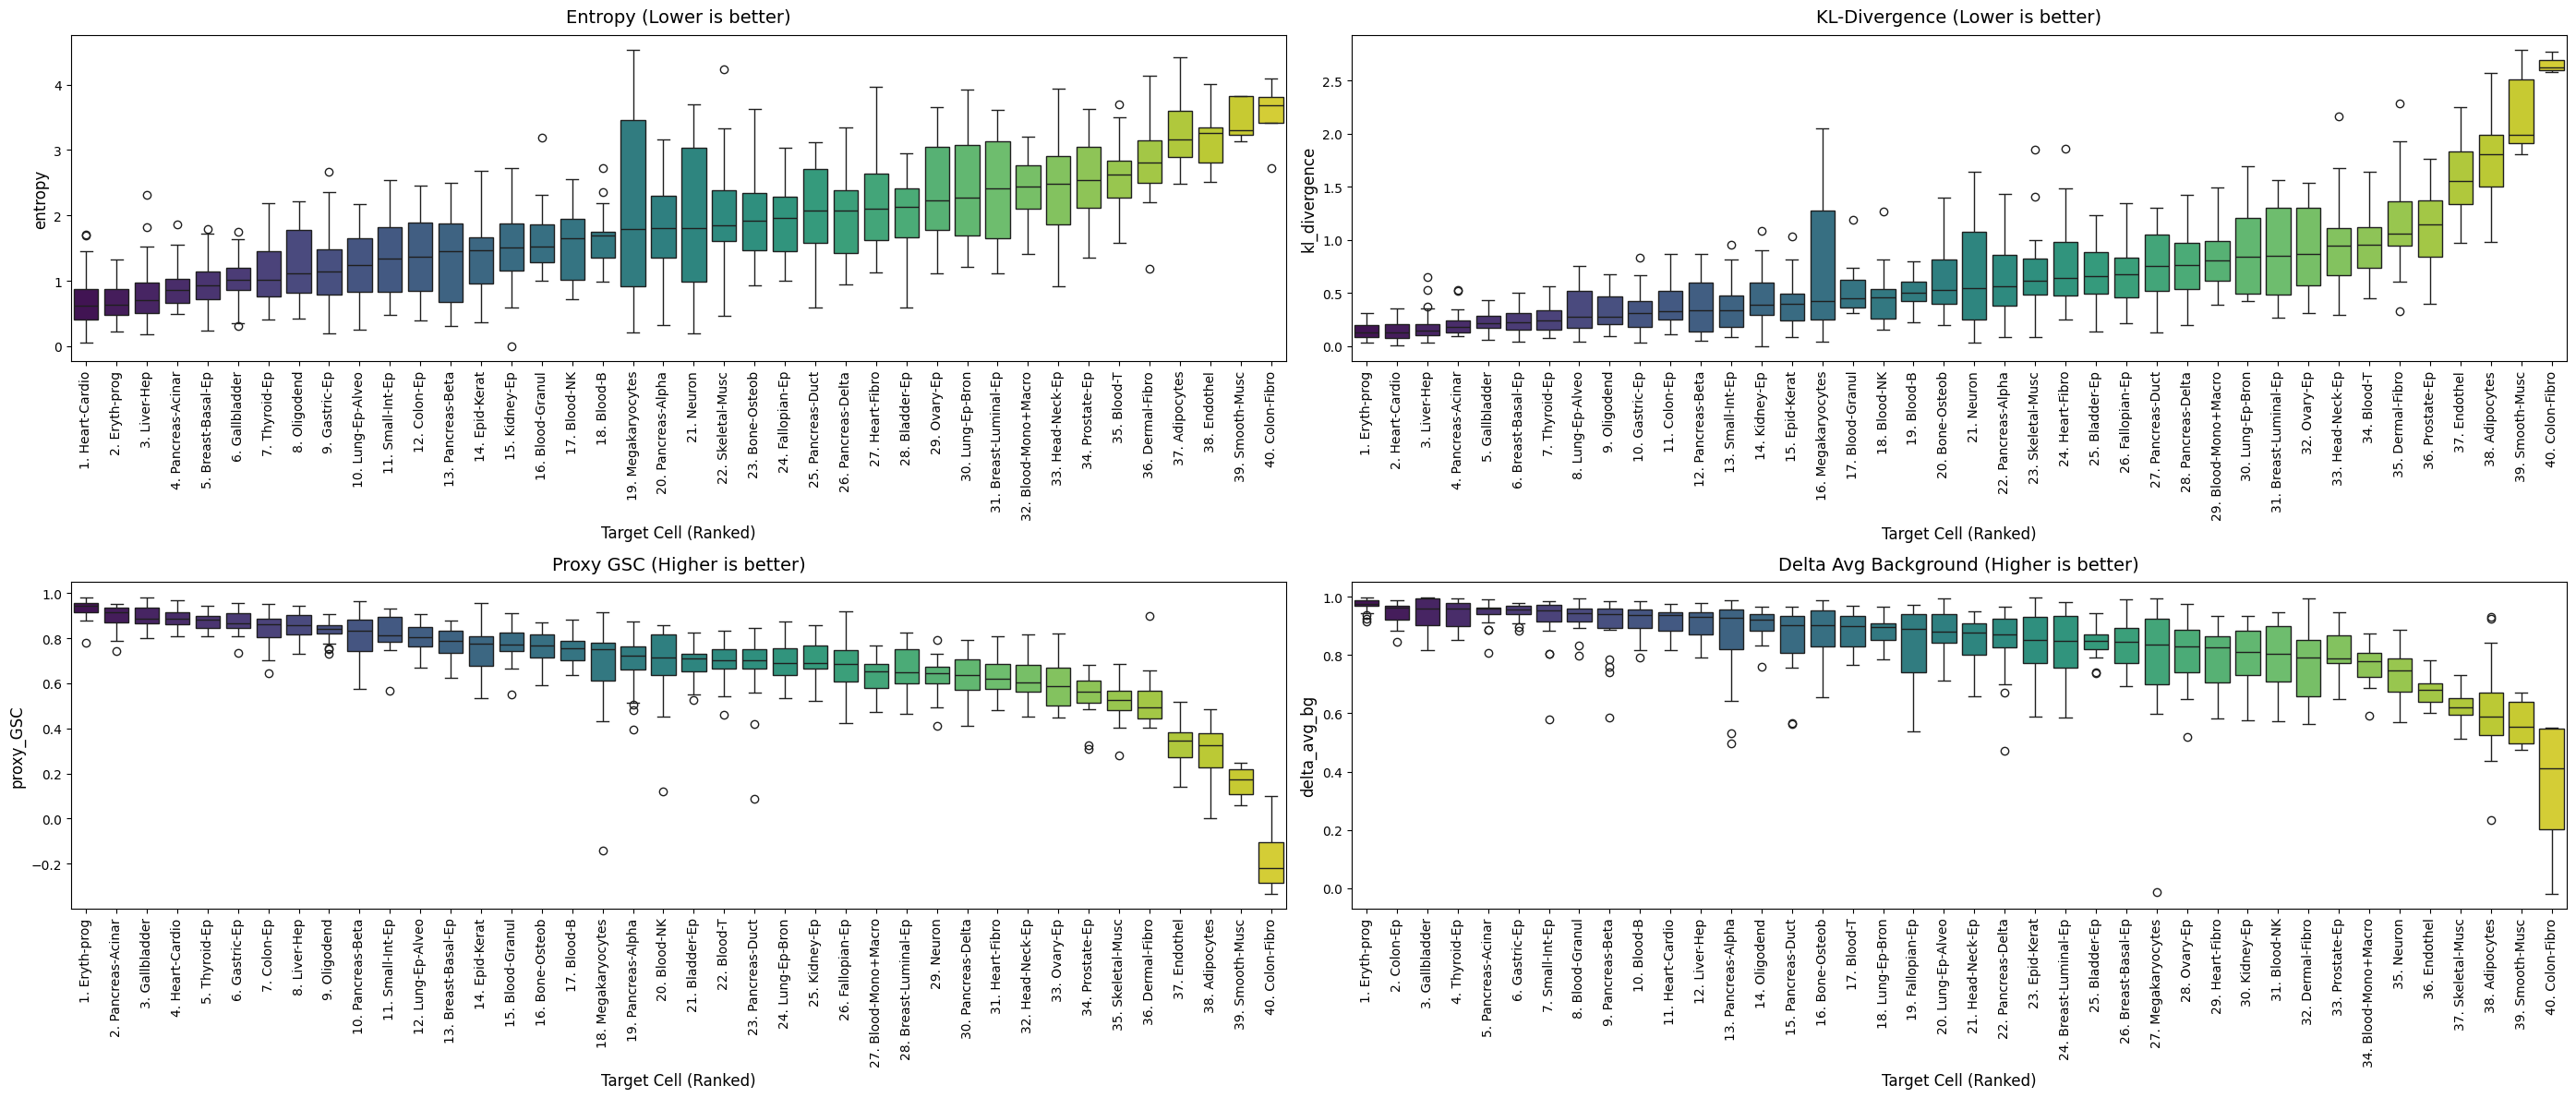

In [24]:
plot_methylation_metrics(scored_df.dropna())

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_target_regions_boxplot(df, selected_target):
    """
    Plots a boxplot of unmethylated reads percentage across all cell types 
    for regions belonging to a single selected target cell type.
    """
    # Filter the dataframe for the selected target cell type
    target_df = df[df['target'] == selected_target]
    
    # Identify metadata vs cell type columns
    metadata_cols = ['chr', 'start', 'end', 'startCpG', 'endCpG', 'target', 'name', 'direction']
    cell_type_cols = [c for c in df.columns if c not in metadata_cols]
    
    # Reshape data to long format so seaborn can easily plot it
    melted_df = target_df.melt(
        id_vars=['name'], 
        value_vars=cell_type_cols, 
        var_name='Cell_Type', 
        value_name='Unmethylated_Reads_Percentage'
    )
    
    # Calculate medians to sort the x-axis from highest to lowest
    medians = melted_df.groupby('Cell_Type')['Unmethylated_Reads_Percentage'].median().sort_values(ascending=False)
    
    # Make a color palette: Red for the target cell type, light blue for background types
    palette = ['red' if ct == selected_target else 'skyblue' for ct in medians.index]
    
    # Create the plot
    plt.figure(figsize=(18, 8))
    sns.boxplot(
        data=melted_df, 
        x='Cell_Type', 
        y='Unmethylated_Reads_Percentage', 
        order=medians.index,
        palette=palette
    )
    
    # Formatting the aesthetics
    plt.title(f'Percentage of Unmethylated Reads across Cell Types\n(Showing Regions Targeting: {selected_target})', fontsize=16)
    plt.xlabel('Cell Type', fontsize=12)
    plt.ylabel('Unmethylated Reads (%)', fontsize=12)
    plt.xticks(rotation=90, ha='center', fontsize=10)  # Rotated for readability
    plt.tight_layout()
    
    # Save or Show
    plt.savefig(f'{selected_target}_boxplot.png')
    plt.show()

# Run the function on your full DataFrame:
# plot_target_regions_boxplot(df, 'Eryth-prog')

/tmp/ipykernel_329002/3473393595.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


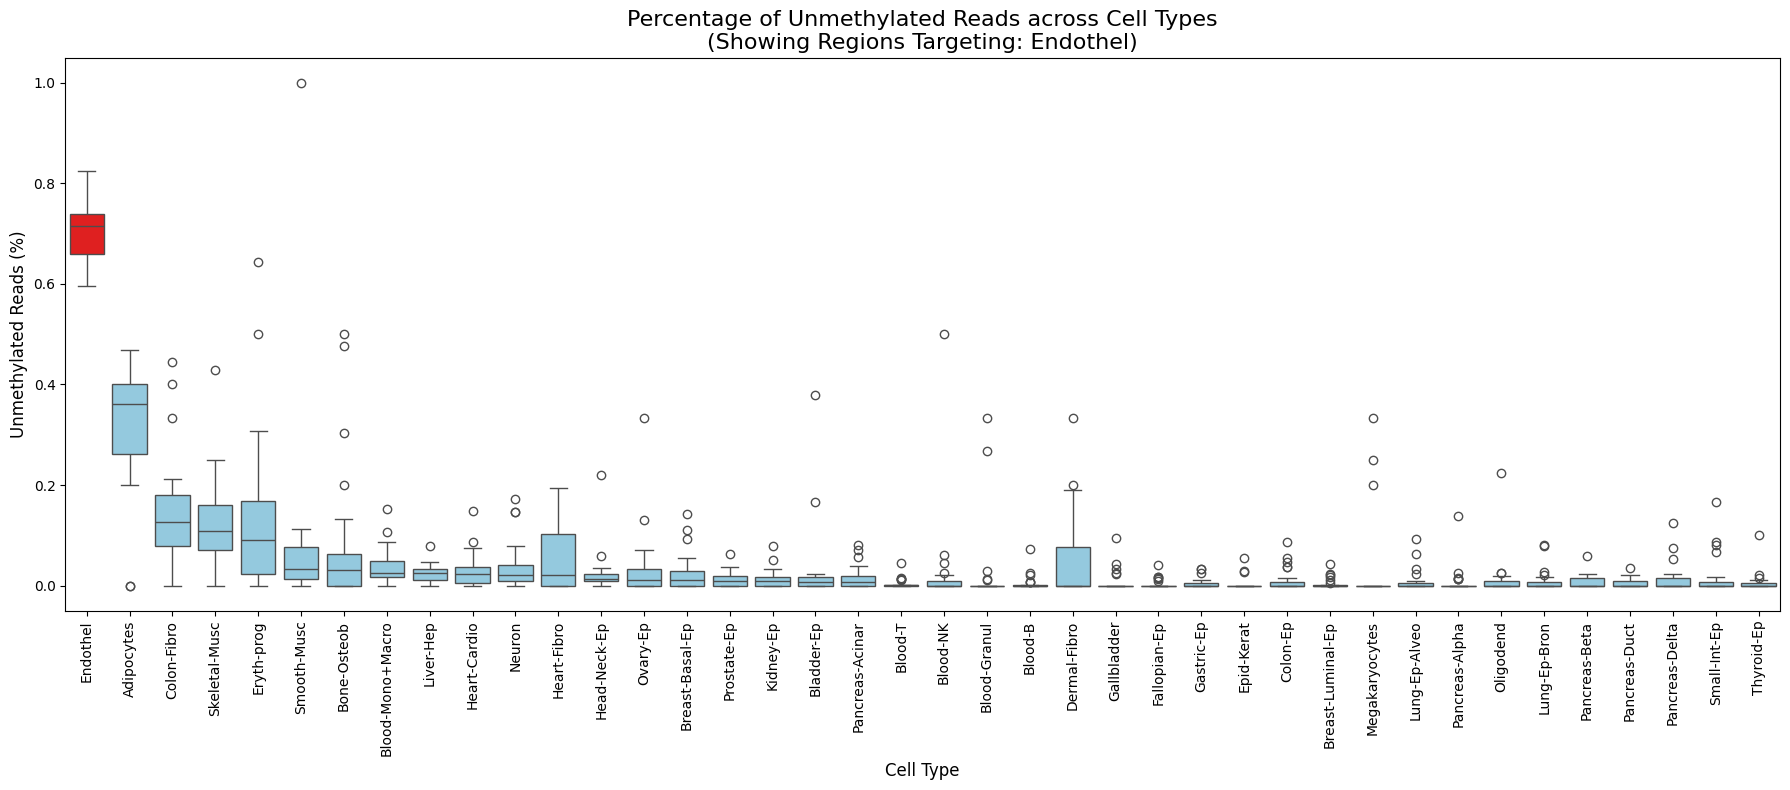

In [68]:
plot_target_regions_boxplot(atlas, selected_target="Endothel")

#### Analyze, if better regions can be selected from top-250

In [55]:
atlas_location = "../../UXM_deconv/supplemental/Atlas.U250.l4.hg38.full.tsv"
atlas250, ref_cells = load_atlas(atlas_location)
atlas250 = atlas250.sort_values(by=["chr", "start", "end"], ascending=True).reset_index(drop=True)

In [56]:
scored_df250 = score_methylation_regions(atlas250)

In [58]:
targets = set(scored_df250["target"])

In [59]:
scored_df250_sorted = scored_df250.dropna().sort_values("proxy_GSC", ascending=False)

In [60]:
subset = []
for target in targets:
    subset.append(scored_df250_sorted[scored_df250_sorted["target"]==target].head(25))

In [61]:
subset = pd.concat(subset)

In [ ]:
subset.to_csv("Atlas.U25.l4.hg38.gscSorted.full.csv",index=False)

In [66]:
extended_atals = pd.concat([scored_df, subset])

In [69]:
extended_atals.drop_duplicates(inplace=True)

In [70]:
extended_atals.to_csv("extended_Loyfer_atlas_hg38.csv")

In [73]:
help(extended_atals[["chr", "start", "end"]].to_csv)

Help on method to_csv in module pandas.core.generic:

to_csv(path_or_buf: 'FilePath | WriteBuffer[bytes] | WriteBuffer[str] | None' = None, *, sep: 'str' = ',', na_rep: 'str' = '', float_format: 'str | Callable | None' = None, columns: 'Sequence[Hashable] | None' = None, header: 'bool_t | list[str]' = True, index: 'bool_t' = True, index_label: 'IndexLabel | None' = None, mode: 'str' = 'w', encoding: 'str | None' = None, compression: 'CompressionOptions' = 'infer', quoting: 'int | None' = None, quotechar: 'str' = '"', lineterminator: 'str | None' = None, chunksize: 'int | None' = None, date_format: 'str | None' = None, doublequote: 'bool_t' = True, escapechar: 'str | None' = None, decimal: 'str' = '.', errors: 'OpenFileErrors' = 'strict', storage_options: 'StorageOptions | None' = None) -> 'str | None' method of pandas.core.frame.DataFrame instance
    Write object to a comma-separated values (csv) file.

    Parameters
    ----------
    path_or_buf : str, path object, file-like object

In [75]:
extended_atals[["chr", "start", "end"]].to_csv("extended_Loyfer_atlas_hg38.bed",index=False, sep="\t")

/tmp/ipykernel_405796/797545497.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_405796/797545497.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_405796/797545497.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_405796/797545497.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


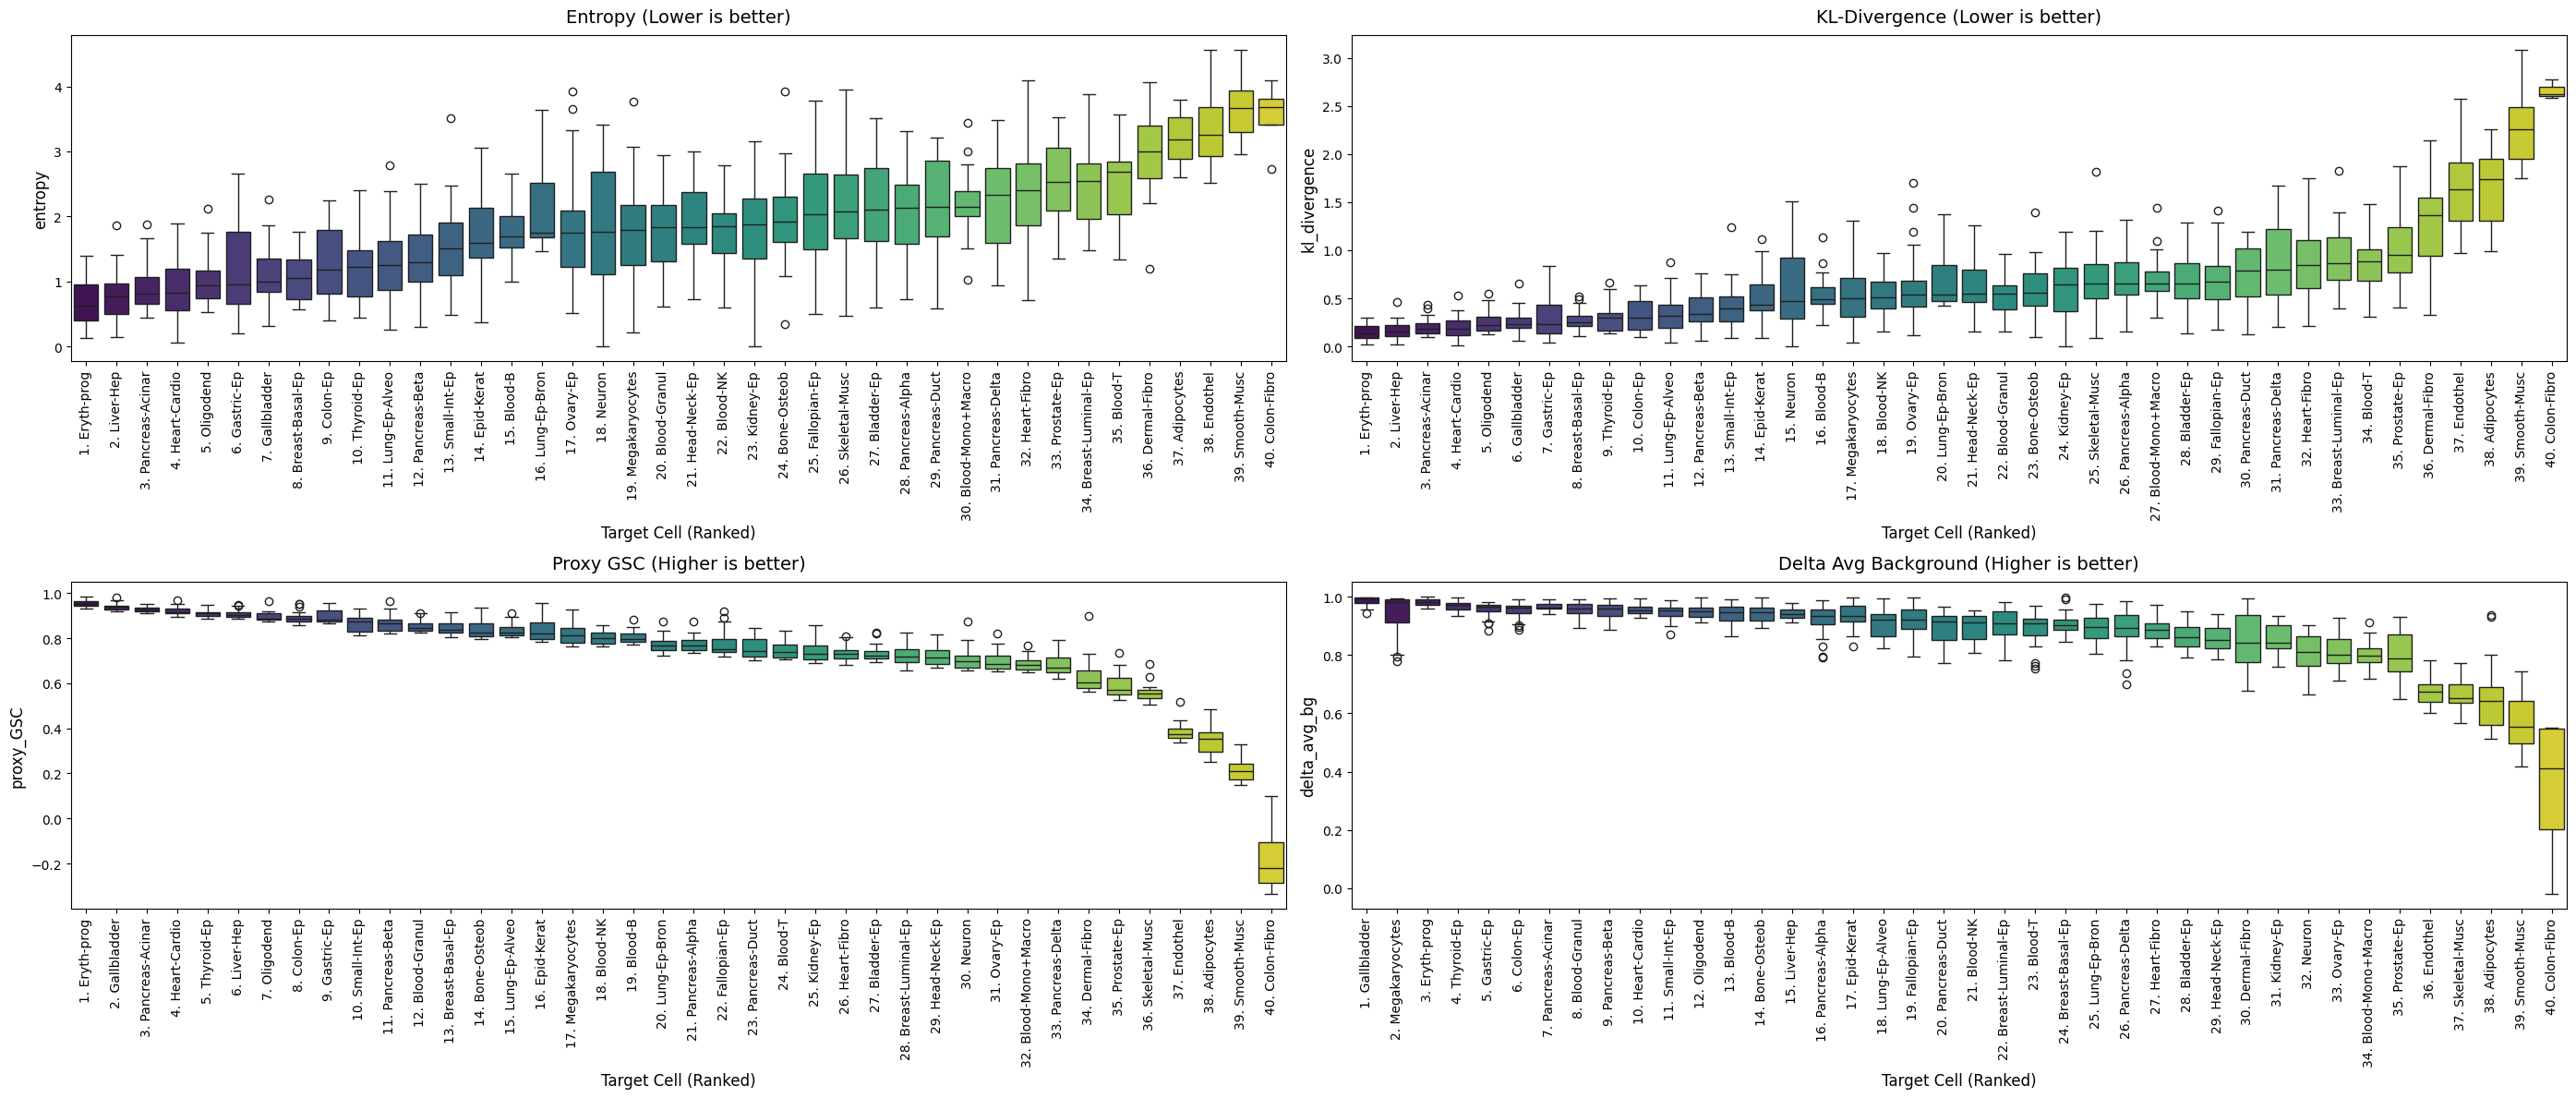

In [63]:
plot_methylation_metrics(subset)